In [1]:
import pandas as pd
import os
import sys
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import json
import joblib
import ast

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

In [2]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

In [3]:
data["classification"].value_counts()

classification
valid    56312
Name: count, dtype: int64

In [4]:
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df))

54754


In [5]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

n_configs = 10000
sampled_df = validated_df.sample(n=n_configs, random_state=42).reset_index(drop=True)

# Explode both columns together
df_exploded = sampled_df[columns].explode(['ifc', 'Ucell'], ignore_index=True)

print("\nExploded DataFrame:")
print(len(df_exploded))
df_exploded.head()


Exploded DataFrame:
310000


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Ucell,ifc,SHA256
0,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.971062,0.000813,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
1,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.927253,0.100812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
2,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.8958,0.200812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
3,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.87028,0.300812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
4,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.848665,0.400812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...


In [6]:
X = df_exploded[list(parameter_ranges.keys()) + ['ifc']]
y = df_exploded['Ucell']

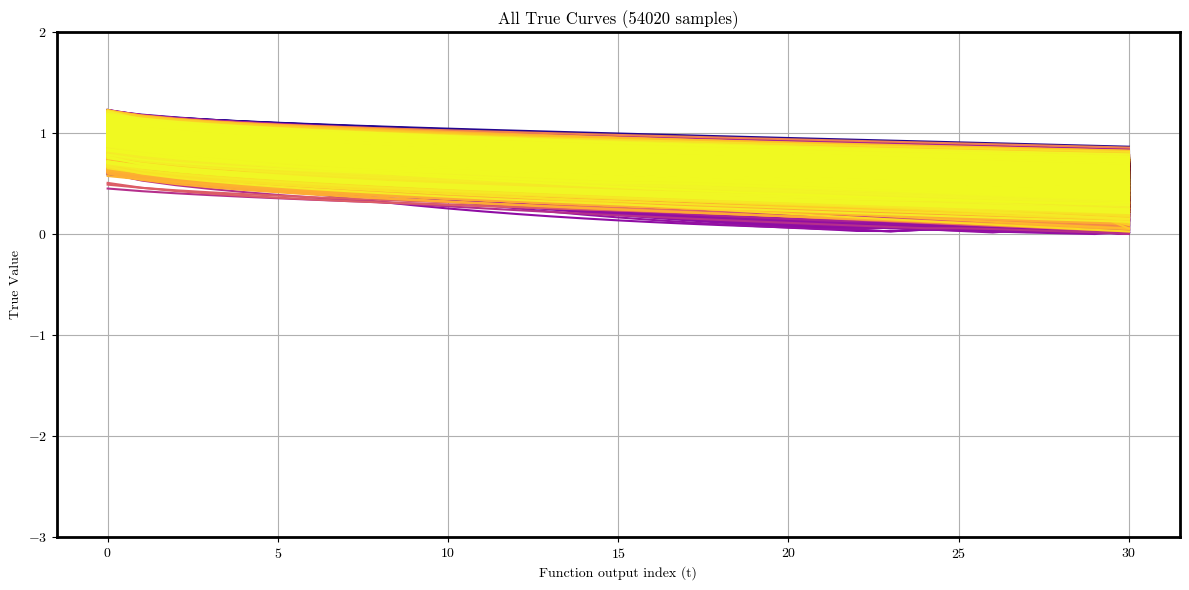

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_true_curves(Y_true):
    """
    Plot all true curves from Y_true.
    
    Args:
        Y_true (np.array): True function outputs, shape (n_samples_total, T)
    """
    n_samples = Y_true.shape[0]
    
    plt.figure(figsize=(12, 6))
    colors = plt.cm.plasma(np.linspace(0, 1, n_samples))
    
    for idx, color in zip(range(n_samples), colors):
        t = np.arange(Y_true.shape[1])
        plt.plot(t, Y_true[idx], label=f'Sample {idx}', color=color)
    
    plt.xlabel('Function output index (t)')
    plt.ylabel('True Value')
    plt.title(f'All True Curves ({n_samples} samples)')
    plt.grid(True)
    plt.ylim(-3, 2)
    # Uncomment if you want legend:
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

all_Y = np.array(data['Ucell'].tolist())

mask_negative = np.any(all_Y < 0, axis=1)

# Get those curves
curves_with_negative = all_Y[mask_negative]
positive_curves = all_Y[~mask_negative]
plot_all_true_curves(positive_curves)


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel as C
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

def nested_cv_train_with_groups(X, y, groups, model_name='rf', outer_splits=5, inner_splits=3, random_state=42):
    """
    Nested CV with GroupKFold (groups provided) and grid search for GP, XGBoost, or RF.
    """

    print(f"\n[INFO] Starting nested CV for model: {model_name}")
    print(f"[INFO] Total samples: {len(X)}, grouped into {len(np.unique(groups))} unique groups")
    print(f"[INFO] Outer CV folds: {outer_splits}, Inner CV folds: {inner_splits}\n")

    outer_cv = GroupKFold(n_splits=outer_splits)
    inner_cv = GroupKFold(n_splits=inner_splits)

    # Choose model and grid
    if model_name == 'rf':
        estimator = RandomForestRegressor(random_state=random_state)
        param_grid = {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5, 10]
        }
    elif model_name == 'xgboost':
        estimator = XGBRegressor(random_state=random_state, verbosity=0)
        param_grid = {
            "n_estimators": [300, 500, 700],
            "max_depth": [6, 8, 10],
            "learning_rate": [0.01, 0.05],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    elif model_name == 'gp':
        kernel = C(1.0) * RBF(length_scale=1.0)
        estimator = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        param_grid = {
            'kernel': [
                C(1.0, (0.1, 10.0)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
                C(1.0, (0.1, 10.0)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5),
                C(1.0, (0.1, 10.0)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5),
                C(1.0, (0.1, 10.0)) * RationalQuadratic(length_scale=1.0, alpha=0.1)
            ],
            'alpha': [1e-10, 1e-5, 1e-2]
        }
    else:
        raise ValueError(f"[ERROR] Unknown model name: {model_name}")

    # Count total param combinations
    from itertools import product
    total_combinations = len(list(product(*param_grid.values())))
    print(f"[INFO] Defined hyperparameter grid with {total_combinations} combinations\n")

    r2_scores = []
    mse_scores = []
    mae_scores = []
    best_params_list = []

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), 1):
        print(f"[INFO] → Starting outer fold {outer_fold}/{outer_splits}")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        print(f"[INFO]    Train size: {X_train.shape}, Test size: {X_test.shape}")
        print(f"[INFO]    Performing inner grid search ({inner_splits}-fold CV)...")

        grid_search = GridSearchCV(
            estimator,
            param_grid,
            cv=inner_cv.split(X_train, y_train, groups=groups_train),
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"[INFO]    Best hyperparameters for fold {outer_fold}: {best_params}")

        y_pred = best_model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        r2_scores.append(r2)
        mse_scores.append(mse)
        mae_scores.append(mae)
        best_params_list.append(best_params)

        print(f"[INFO]    Fold {outer_fold} performance — R²: {r2:.4f}, RMSE: {np.sqrt(mse):.4f}, MAE: {mae:.4f}\n")

    print("[INFO] Finished all folds.")
    print("[INFO] → Summary:")
    print(f"   R2 mean ± std:  {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"   RMSE mean ± std: {np.sqrt(np.mean(mse_scores)):.4f} ± {np.std(np.sqrt(mse_scores)):.4f}")
    print(f"   MAE mean ± std:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}\n")

    metrics = {
        'R2_mean': np.mean(r2_scores),
        'R2_std': np.std(r2_scores),
        'R2_all': r2_scores,
        'MSE_mean': np.mean(mse_scores),
        'MSE_std': np.std(mse_scores),
        'MSE_all': mse_scores,
        'MAE_mean': np.mean(mae_scores),
        'MAE_std': np.std(mae_scores),
        'MAE_all': mae_scores
    }

    return metrics, best_params_list

In [9]:
def save_nested_cv_results(X, y, groups, model_name, nested_cv_fn, 
                            save_dir='results', run_name='model_run',
                            outer_splits=5, inner_splits=3, random_state=42):
    """
    Runs nested CV using a given function, saves metrics, best params, and retrains final model.
    
    Parameters:
    - X, y, groups: Input features, targets, and grouping info
    - model_name: 'rf', 'xgboost', 'gp', etc. (must be supported by nested_cv_fn)
    - nested_cv_fn: function(X, y, groups, model_name, outer_splits, inner_splits, random_state)
                    must return (metrics_dict, best_params_list)
    - save_dir: folder to store results
    - run_name: identifier for files
    - outer_splits, inner_splits: CV configuration
    - random_state: reproducibility

    Returns:
    - final_model: trained on all data with best hyperparameters
    - metrics: dict of evaluation scores
    - best_params_list: list of best param dicts per outer fold
    """

    os.makedirs(save_dir, exist_ok=True)

    # Run nested CV
    metrics, best_params_list = nested_cv_fn(
        X.to_numpy(), y.to_numpy(), groups.to_numpy(),
        model_name=model_name,
        outer_splits=outer_splits,
        inner_splits=inner_splits,
        random_state=random_state
    )

    # Save metrics & best params
    metrics_path = os.path.join(save_dir, f"{run_name}_metrics.json")
    params_path = os.path.join(save_dir, f"{run_name}_best_params.json")
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    with open(params_path, 'w') as f:
        json.dump(best_params_list, f, indent=4)

    print(f"Saved metrics to {metrics_path}")
    print(f"Saved best params to {params_path}")

    best_params_final = best_params_list[0]  # Could be improved with voting

    if model_name == 'rf':
        model = RandomForestRegressor(random_state=random_state, **best_params_final)
    elif model_name == 'xgboost':
        model = XGBRegressor(random_state=random_state, **best_params_final)
    elif model_name == 'gp':
        model = GaussianProcessRegressor(normalize_y=True, random_state=random_state, **best_params_final)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    model.fit(X, y)
    model_path = os.path.join(save_dir, f"{run_name}_final_model.pkl")
    joblib.dump(model, model_path)
    print(f"Saved final model to {model_path}")

    return model, metrics, best_params_list

In [ ]:
final_model_rf, metrics_rf, best_params_rf = save_nested_cv_results(
    X, y, df_exploded['SHA256'],
    model_name='rf',  # or 'xgboost' or 'gp'
    nested_cv_fn=nested_cv_train_with_groups,
    save_dir='../results/sm/randomForest',
    run_name='randomForest',
)


[INFO] Starting nested CV for model: rf
[INFO] Total samples: 310000, grouped into 9958 unique groups
[INFO] Outer CV folds: 5, Inner CV folds: 3

[INFO] Defined hyperparameter grid with 27 combinations

[INFO] → Starting outer fold 1/5
[INFO]    Train size: (248000, 14), Test size: (62000, 14)
[INFO]    Performing inner grid search (3-fold CV)...


In [ ]:
final_model_xgb, metrics_xgb, best_params_xgb = save_nested_cv_results(
    X, y, df_exploded['SHA256'],
    model_name='xgboost',  # or 'xgboost' or 'gp'
    nested_cv_fn=nested_cv_train_with_groups,
    save_dir='../results/sm/xgboost',
    run_name='xgboost',
)


[INFO] Starting nested CV for model: xgboost
[INFO] Total samples: 310000, grouped into 9958 unique groups
[INFO] Outer CV folds: 5, Inner CV folds: 3

[INFO] Defined hyperparameter grid with 72 combinations

[INFO] → Starting outer fold 1/5
[INFO]    Train size: (248000, 14), Test size: (62000, 14)
[INFO]    Performing inner grid search (3-fold CV)...
